## RQ3: Underutilized Routes and Stops

### Introduction

**Research Question**:

Which routes and stops are underutilized, and how can this be identified using ridership data?

This research question focuses on identifying routes and stops with consistently low ridership across the B-Line system. By analyzing stop-level and route-level boardings, we aim to highlight underused areas of the network. This insight can help optimize route planning, reallocate resources, or modify service to better match rider demand.

## Variables

**Dependent Variable (Outcome):**

boardings – number of passengers boarding at each stop (from RidershipData.csv)

**Independent Variables (Predictors):**

stop_id – unique identifier for each stop (in RidershipData.csv)

route_id – associated route (in RidershipData.csv)

date – for temporal context (in RidershipData.csv)

location – optional coordinates or stop name (if available)

These variables are sourced from RidershipData.csv, which provides stop-level boarding data over time. Spatial attributes (e.g., stop location) may be included from a supplemental stop metadata file if available.

## Statistical Plan

**Preprocessing:**

Aggregate boardings per stop_id and route_id over time

Normalize or average boardings per time unit (e.g., per day)


Methods:These analyses will help detect consistently low-performing stops or routes, supporting decisions on consolidation, schedule adjustments, or targeted improvements:

- **Descriptive Statistics**: Identify stops/routes with low average boardings

- **Percentile Ranking**: Flag bottom 10–15% as underutilized

- **Anomaly Detection**: Use methods like Isolation Forest or Z-scores to find statistically low-usage points



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# === FILE PATHS ===
BOARDINGS_PATH = "PATH_TO_YOUR_BOARDINGS_FILE.csv"  # <-- change
STOP_MAP_PATH  = r"/mnt/data/B-Line Stops Map_data_cleaned.csv"  # your uploaded file (edit if needed)

# === COLUMN NAMES (edit to match your data) ===
TIMESTAMP_COL = "timestamp"     # boarding datetime
ROUTE_COL     = "route_long_name"    # route name/number
STOP_COL      = "stop_id"       # stop identifier
TRIP_COL      = "trip_id"       # unique trip/run identifier (if you have it)
VEHICLE_COL   = "vehicle_id"    # optional, only used if TRIP_COL missing

In [3]:
df = pd.read_csv("C:/Users/zelaskar/Box/2024 Zakir Elaskar/data/Combined datasets/validation_combined_union.csv")
stops_map = pd.read_csv("C:/Users/zelaskar/Box/2024 Zakir Elaskar/data/Combined datasets/B-Line Stops Map_data_cleaned.csv")

print("Boardings shape:", df.shape)
print("Stops map shape:", stops_map.shape)

print("Boardings columns:", df.columns.tolist())
print("Stops map columns:", stops_map.columns.tolist())

C:\Users\zelaskar\AppData\Local\Temp\ipykernel_2976\2546929815.py:1: DtypeWarning: Columns (10,17,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/zelaskar/Box/2024 Zakir Elaskar/data/Combined datasets/validation_combined_union.csv")


Boardings shape: (134548, 26)
Stops map shape: (20738, 7)
Boardings columns: ['timestamp', 'validation_id', 'user_id', 'pass_id', 'pass_agency_id', 'fare_id', 'fare_type', 'rider_type', 'validator_id', 'vehicle_number', 'stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon', 'trip_id', 'gtfs_route_id', 'route_id', 'route_long_name', 'all_rts', 'riders_by_rt', 'origin', 'validator_lat', 'validator_lon', 'id', 'source_file']
Stops map columns: ['stop_lat', 'stop_lon', 'route_id', 'near_land', 'stop_id', 'street', 'number_of_riders']


### Data preparation

We load the combined B-Line validation dataset and a cleaned stops map:

- `df`: full validation dataset with one record per boarding, including timestamp, route, stop, and trip identifiers.
- `stops_map`: stop-level metadata including latitude/longitude and nearby land use (`near_land`).

We convert the raw timestamp to a proper datetime and derive:
- `date`: service date (YYYY-MM-DD).
- `dow`: day of week (Monday–Sunday).
- `hour`: hour of day (0–23).

These temporal features are used later to model time-of-day and day-of-week patterns in ridership.

In [4]:
# Parse timestamp
df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors="coerce")
df = df.dropna(subset=[TIMESTAMP_COL])

# Create service date + time features
df["date"] = df[TIMESTAMP_COL].dt.date
df["dow"] = df[TIMESTAMP_COL].dt.day_name()
df["hour"] = df[TIMESTAMP_COL].dt.hour

# Basic checks
needed = [ROUTE_COL, STOP_COL]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

### Trip-level aggregation and route utilization

We first aggregate boardings to the **trip level**:

- `trip_df`: one row per `trip_id` × `route_long_name`, with `boardings_per_trip` equal to the number of boardings on that trip.
- `trip_time` / `trip_time_full`: adds `date`, `dow`, and `hour` for each trip, using the first observed boarding time on that trip.

We then summarize trip-level utilization by route:

- `route_summary` groups `trip_df` by `route_long_name` and computes:
  - `median_boardings`: median boardings per trip (typical utilization).
  - `mean_boardings`: mean boardings per trip.
  - `std_boardings`: standard deviation of boardings per trip.
  - `trips`: total number of observed trips on the route.

These descriptive statistics provide a baseline ranking of routes by typical (median) trip-level ridership, and are later used to flag descriptively “underutilized” routes as those in the bottom 15% of median boardings.

In [5]:
trip_df = (
    df.groupby([TRIP_COL, ROUTE_COL])
      .size()
      .reset_index(name="boardings_per_trip")
)

trip_df.head()

,trip_id,route_long_name,boardings_per_trip
0,0002cb24-fc47-45f7-bae8-ed2acec5e054,E. 8th Street,4
1,00059f62-1536-4ede-9d82-1ff84189ed9b,Bruce / Manzanita,3
2,0007e49a-8ba3-4d4c-afaf-0d07d7194796,Mangrove,37
3,000bca34-308a-4af0-b282-70ec5316e57f,E. 8th Street,1
4,00196df3-cf2d-4eed-b79a-a74813f6e6e7,Esplanade / Lassen,3


In [6]:
trip_time = (
    df.groupby(TRIP_COL)
      .agg(
          route_long_name=(ROUTE_COL, "first"),
          date=("date", "first"),
          dow=("dow", "first"),
          hour=("hour", "first")
      )
      .reset_index()
)

# Merge with boardings_per_trip
trip_df = trip_time.merge(
    trip_df,
    on=[TRIP_COL, "route_long_name"],
    how="left"
)

trip_df.head()

,trip_id,route_long_name,date,dow,hour,boardings_per_trip
0,0002cb24-fc47-45f7-bae8-ed2acec5e054,E. 8th Street,2024-06-28,Friday,10,4.0
1,00059f62-1536-4ede-9d82-1ff84189ed9b,Bruce / Manzanita,2025-01-06,Monday,17,3.0
2,0007e49a-8ba3-4d4c-afaf-0d07d7194796,Mangrove,2024-05-31,Friday,14,37.0
3,000bca34-308a-4af0-b282-70ec5316e57f,E. 8th Street,2023-09-02,Saturday,13,1.0
4,00196df3-cf2d-4eed-b79a-a74813f6e6e7,Esplanade / Lassen,2024-11-30,Saturday,14,3.0


In [7]:
route_summary = (
    trip_df
    .groupby("route_long_name")["boardings_per_trip"]
    .agg(
        median_boardings="median",
        mean_boardings="mean",
        std_boardings="std",
        trips="count"
    )
    .reset_index()
    .sort_values(by="median_boardings", ascending=False)
)

route_summary[
    ["median_boardings", "mean_boardings", "std_boardings"]
] = route_summary[
    ["median_boardings", "mean_boardings", "std_boardings"]
].round(2)

route_summary

,route_long_name,median_boardings,mean_boardings,std_boardings,trips
9,Magalia - Chico,14.0,29.44,38.15,231
2,Chico - Oroville,11.0,25.12,36.66,687
18,Park/MLK/Forest,9.0,26.83,37.78,75
0,Bruce / Manzanita,8.0,13.96,18.39,288
14,Oroville - Biggs,7.0,11.94,13.29,160
1,Cedar Loop,7.0,16.32,30.79,93
22,Thermalito,7.0,13.69,23.26,233
6,Esplanade/SR99,7.0,14.57,20.87,630
3,Chico Airport Express,6.5,11.65,13.52,78
7,First / East,6.0,12.91,16.18,873


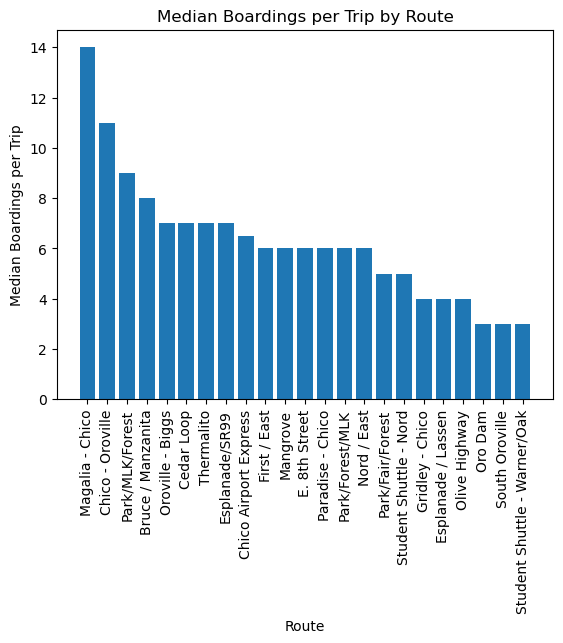

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(route_summary["route_long_name"],
        route_summary["median_boardings"])

plt.xticks(rotation=90)
plt.xlabel("Route")
plt.ylabel("Median Boardings per Trip")
plt.title("Median Boardings per Trip by Route")
plt.show()

Route-Level Median Utilization (Bar Chart)

This figure displays the median number of boardings per trip for each route, ranked from highest to lowest. The median is used to represent typical trip-level utilization, as it is robust to extreme values and skewness in ridership distributions.

Substantial variation is observed across routes. The highest-utilization route is Magalia–Chico, with a median of approximately 14 boardings per trip, followed by Chico–Oroville and Park/MLK/Forest. In contrast, several routes exhibit median utilization levels of 3 to 4 boardings per trip.

Most routes cluster between 5 and 7 boardings per trip, suggesting moderate utilization across much of the system. However, the presence of a small number of higher-utilization routes indicates uneven demand across the network.

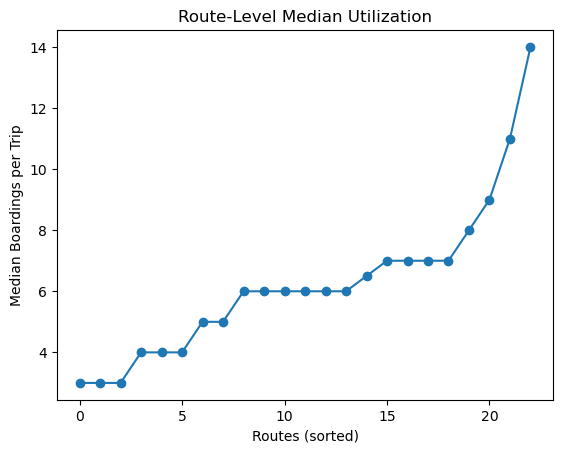

In [9]:
plt.figure()
plt.plot(route_summary["median_boardings"].sort_values().values,
         marker="o")

plt.xlabel("Routes (sorted)")
plt.ylabel("Median Boardings per Trip")
plt.title("Route-Level Median Utilization")
plt.show()

Distribution of Route-Level Medians (Sorted Dot Plot)

The sorted dot plot visualizes the distribution of median boardings per trip across routes without labeling specific route names. This representation emphasizes overall dispersion and inequality in utilization.

The majority of routes fall within a relatively narrow band of utilization, while a small number of routes exhibit substantially higher median boardings per trip. The sharp upward slope among the highest-ranked routes suggests concentration of stronger demand within a limited subset of the network.

This pattern indicates that utilization is not evenly distributed across routes.

In [10]:
route_day = (
    trip_df
    .groupby(["route_long_name", "dow"])["boardings_per_trip"]
    .median()
    .reset_index()
)

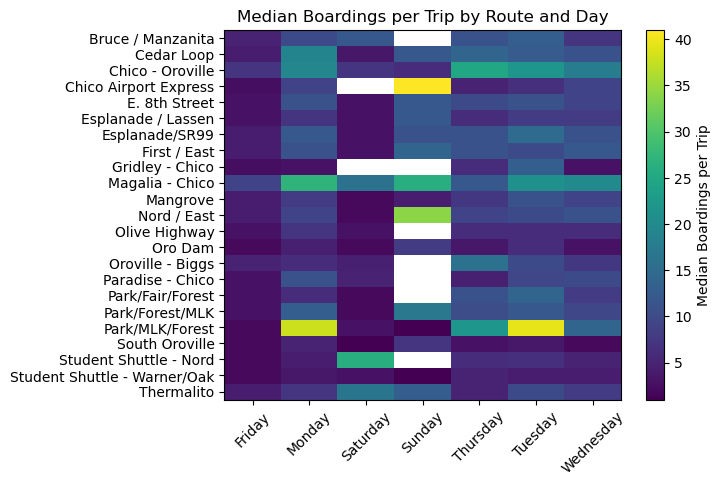

In [11]:
pivot_day = route_day.pivot(
    index="route_long_name",
    columns="dow",
    values="boardings_per_trip"
)

plt.figure()
plt.imshow(pivot_day, aspect="auto")
plt.colorbar(label="Median Boardings per Trip")

plt.xticks(range(len(pivot_day.columns)),
           pivot_day.columns,
           rotation=45)

plt.yticks(range(len(pivot_day.index)),
           pivot_day.index)

plt.title("Median Boardings per Trip by Route and Day")
plt.show()

Route × Day-of-Week Heatmap

The heatmap presents median boardings per trip by route and day of the week. This allows temporal patterns to emerge directly from the data without imposing predefined weekday or weekend classifications.

Several routes exhibit consistently higher utilization during weekdays compared to weekends, suggesting commuter-oriented demand. Other routes show more stable utilization across all days, indicating potentially mixed or local travel patterns.

The heterogeneity across routes demonstrates that temporal demand patterns vary meaningfully across the network rather than following a uniform system-wide trend.

In [12]:
route_hour = (
    trip_df
    .groupby(["route_long_name", "hour"])["boardings_per_trip"]
    .median()
    .reset_index()
)

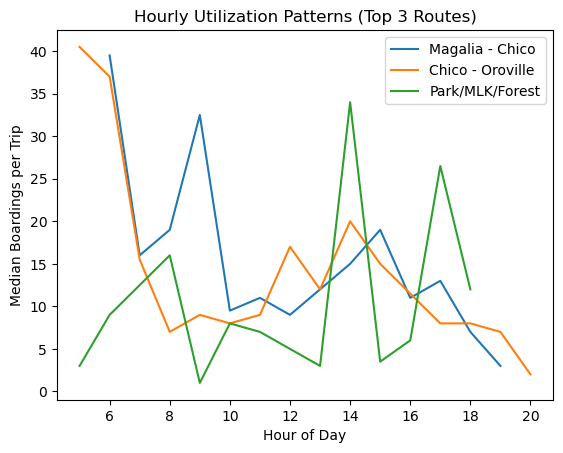

In [13]:
top_routes = route_summary.head(3)["route_long_name"]

plt.figure()

for r in top_routes:
    subset = (
        route_hour[route_hour["route_long_name"] == r]
        .sort_values("hour")
    )
    plt.plot(
        subset["hour"],
        subset["boardings_per_trip"],
        label=r
    )

plt.xlabel("Hour of Day")
plt.ylabel("Median Boardings per Trip")
plt.title("Hourly Utilization Patterns (Top 3 Routes)")
plt.legend()
plt.show()

Hour-of-Day Patterns for Top 3 Routes

This figure illustrates hourly median boardings per trip for the three highest-utilization routes. By focusing on the most heavily used routes, the analysis highlights within-route temporal variation.

Distinct peak periods are observed across routes, although peak timing differs. Some routes display strong early-day demand, while others show elevated ridership during midday or afternoon hours. The variation in peak structure suggests differences in route function, such as commuter travel versus general-purpose mobility.

Importantly, peak periods are identified empirically from the data rather than defined a priori.

In [14]:
total_by_route = (
    trip_df
    .groupby("route_long_name")["boardings_per_trip"]
    .sum()
    .reset_index()
    .sort_values(by="boardings_per_trip", ascending=False)
)

total_by_route["share"] = (
    total_by_route["boardings_per_trip"] /
    total_by_route["boardings_per_trip"].sum()
)

total_by_route["cumulative_share"] = total_by_route["share"].cumsum()

total_by_route

,route_long_name,boardings_per_trip,share,cumulative_share
2,Chico - Oroville,17255.0,0.142726,0.142726
7,First / East,11267.0,0.093196,0.235922
5,Esplanade / Lassen,11230.0,0.092890,0.328812
11,Nord / East,10488.0,0.086752,0.415564
4,E. 8th Street,9361.0,0.077430,0.492994
17,Park/Forest/MLK,9267.0,0.076653,0.569647
6,Esplanade/SR99,9177.0,0.075908,0.645555
10,Mangrove,8525.0,0.070515,0.716070
9,Magalia - Chico,6801.0,0.056255,0.772325
0,Bruce / Manzanita,4020.0,0.033252,0.805577


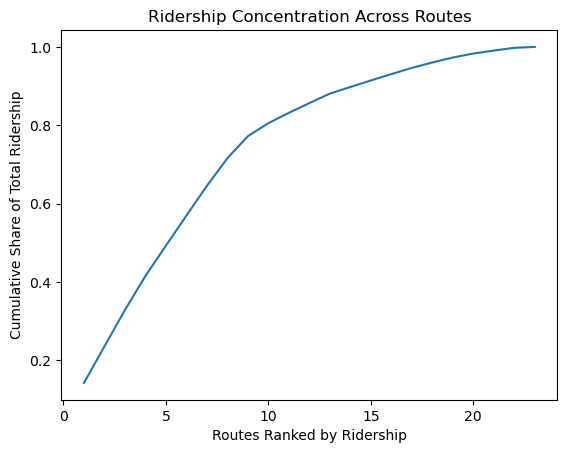

In [15]:
plt.figure()
plt.plot(range(1, len(total_by_route)+1),
         total_by_route["cumulative_share"])

plt.xlabel("Routes Ranked by Ridership")
plt.ylabel("Cumulative Share of Total Ridership")
plt.title("Ridership Concentration Across Routes")
plt.show()

Ridership Concentration Across Routes

To assess whether ridership is evenly distributed or concentrated within a subset of routes, total boardings were aggregated at the route level and ranked from highest to lowest.

Share was calculates, where Share= Total boardings for route/Total boardings across all routes

The cumulative share curve demonstrates that a relatively small number of routes account for a large share of total ridership. The steep initial slope indicates meaningful concentration in the highest-demand routes. As additional routes are included, the cumulative share increases more gradually, reflecting diminishing marginal contributions from lower-utilization routes.

This concentration pattern suggests that system-wide ridership is disproportionately supported by a limited number of routes.

In [16]:
stop_daily = (
    df.groupby(["stop_id", "date"])
      .agg(
          daily_boardings=("validation_id", "count"),
          stop_lat=("stop_lat", "first"),
          stop_lon=("stop_lon", "first")
      )
      .reset_index()
)

In [17]:
stop_util = (
    stop_daily.groupby("stop_id")
              .agg(
                  days_observed=("daily_boardings", "size"),
                  median_daily=("daily_boardings", "median"),
                  mean_daily=("daily_boardings", "mean"),
                  iqr_daily=("daily_boardings", lambda x: np.percentile(x, 75) - np.percentile(x, 25)),
                  total_boardings=("daily_boardings", "sum"),
                  stop_lat=("stop_lat", "first"),
                  stop_lon=("stop_lon", "first")
              )
              .reset_index()
              .sort_values("median_daily", ascending=False)
)

stop_util.head()

,stop_id,days_observed,median_daily,mean_daily,iqr_daily,total_boardings,stop_lat,stop_lon
1807,53c7ba41-6faa-4b77-afc9-f28a7a8316c4,62,30.0,27.403226,10.0,1699,39.728747,-121.842667
320,397.0,177,21.0,20.677966,15.0,3660,39.728747,-121.842667
3810,fd45b93e-8bf1-4b7e-a737-3fe571f5758f,101,20.0,18.227723,10.0,1841,39.728747,-121.842667
655,0afbb7c9-ae9b-4f45-abd9-0d9d735c2ec2,77,16.0,16.493506,9.0,1270,39.728747,-121.842667
1148,2a2095a4-2eb0-4686-bd03-432d528a376f,101,13.0,13.138614,8.0,1327,39.728986,-121.842085


In [22]:
trip_time_full = (
    df.groupby(["trip_id", "route_long_name"])
      .agg(
          boardings_per_trip=("validation_id", "count"),
          hour=("hour", "first"),
          dow=("dow", "first")
      )
      .reset_index()
)

trip_time_full.head()

,trip_id,route_long_name,boardings_per_trip,hour,dow
0,0002cb24-fc47-45f7-bae8-ed2acec5e054,E. 8th Street,4,10,Friday
1,00059f62-1536-4ede-9d82-1ff84189ed9b,Bruce / Manzanita,3,17,Monday
2,0007e49a-8ba3-4d4c-afaf-0d07d7194796,Mangrove,37,14,Friday
3,000bca34-308a-4af0-b282-70ec5316e57f,E. 8th Street,1,13,Saturday
4,00196df3-cf2d-4eed-b79a-a74813f6e6e7,Esplanade / Lassen,3,14,Saturday


In [23]:
route_util = (
    trip_time_full.groupby("route_long_name")
    .agg(
        trips=("boardings_per_trip", "count"),
        total_boardings=("boardings_per_trip", "sum"),
        median_bpt=("boardings_per_trip", "median"),
        mean_bpt=("boardings_per_trip", "mean"),
        iqr_bpt=("boardings_per_trip", lambda x: x.quantile(0.75) - x.quantile(0.25))
    )
    .reset_index()
    .sort_values("median_bpt", ascending=False)
)

route_util.head()

,route_long_name,trips,total_boardings,median_bpt,mean_bpt,iqr_bpt
9,Magalia - Chico,231,6794,14.0,29.411255,31.5
2,Chico - Oroville,687,17227,11.0,25.075691,27.0
18,Park/MLK/Forest,75,2006,9.0,26.746667,30.0
0,Bruce / Manzanita,288,4013,8.0,13.934028,13.5
14,Oroville - Biggs,160,1907,7.0,11.918750,13.0


In [48]:
# --- ROUTE-LEVEL MODEL ---

# Keep reasonable counts to avoid extreme outliers dominating
trip_mod = trip_df.copy()
trip_mod = trip_mod[trip_mod["boardings_per_trip"] >= 0]

# Categorical encodings
trip_mod["dow"] = trip_mod["dow"].astype("category")
trip_mod["route_long_name"] = trip_mod["route_long_name"].astype("category")
trip_mod["hour"] = trip_mod["hour"].astype("category")

# Poisson regression: boardings_per_trip ~ dow (Monday ref) + hour
# IMPORTANT: route is removed from the model so we can compare routes to model expectations later
route_model = smf.glm(
    formula=(
        "boardings_per_trip ~ "
        "C(dow, Treatment(reference='Monday')) + C(hour, Treatment(reference = 10))"
    ),
    data=trip_mod,
    family=sm.families.Poisson()
).fit()

print(route_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:     boardings_per_trip   No. Observations:                 8493
Model:                            GLM   Df Residuals:                     8470
Model Family:                 Poisson   Df Model:                           22
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -93880.
Date:                Tue, 17 Mar 2026   Deviance:                   1.5602e+05
Time:                        16:03:58   Pearson chi2:                 2.70e+05
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9529
Covariance Type:            nonrobust                                         
                                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [49]:
# Add predictions and residuals at the trip level
trip_mod["mu_hat"] = route_model.predict(trip_mod)
trip_mod["resid"] = trip_mod["boardings_per_trip"] - trip_mod["mu_hat"]

# Aggregate to route level
route_effects = (
    trip_mod
    .groupby("route_long_name")
    .agg(
        mean_obs=("boardings_per_trip", "mean"),
        mean_pred=("mu_hat", "mean"),
        mean_resid=("resid", "mean"),
        trips=("boardings_per_trip", "size")
    )
    .reset_index()
)

# Observed / expected ratio
route_effects["resid_ratio"] = route_effects["mean_obs"] / route_effects["mean_pred"]

# Bottom 15% = underutilized routes
q15 = route_effects["resid_ratio"].quantile(0.15)
underutilized_routes_model = (
    route_effects[route_effects["resid_ratio"] <= q15]
    .sort_values("resid_ratio")
)

print(underutilized_routes_model)

                 route_long_name   mean_obs  mean_pred  mean_resid  trips  \
19                South Oroville   5.662252  14.828656   -9.166404    151   
13                       Oro Dam   6.639785  15.752372   -9.112587    186   
21  Student Shuttle - Warner/Oak   7.387681  15.274487   -7.886806    276   
8                Gridley - Chico  11.375000  22.147553  -10.772553     24   

    resid_ratio  
19     0.381845  
13     0.421510  
21     0.483661  
8      0.513601  


C:\Users\zelaskar\AppData\Local\Temp\ipykernel_2976\3132032012.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("route_long_name")


In [53]:
# Convert .ipynb to .qmd (no --to flag needed)
!quarto convert RQ3.ipynb

Converted to RQ3.qmd


In [54]:
!quarto render RQ3.ipynb --to pdf --log-level debug


Quarto version: 1.7.32
[execProcess] C:\Users\zelaskar\AppData\Local\Programs\Quarto\bin\tools\pandoc -f markdown -t markdown -L C:\Users\zelaskar\AppData\Local\Programs\Quarto\share\filters\quarto-internals\leveloneanalysis.lua
[execProcess] Success: true, code: 0
Windows: Using code page 1252
-- Searching for R binary --
Looking for 'Rscript' in QUARTO_R: undefined
Looking for 'Rscript' in R_HOME: undefined
Looking for 'Rscript' in PATH.
[execProcess] CMD /C where Rscript
[execProcess] Success: false, code: 1
Looking for 'Rscript' in Windows Registry.
[execProcess] reg query HKCU\Software\R-core\R /v Current Version
[execProcess] Success: false, code: 1
[execProcess] reg query HKLM\Software\R-core\R /v Current Version
[execProcess] Success: true, code: 0
[execProcess] reg query HKCU\Software\R-core\R\4.4.1 /v InstallPath
[execProcess] Success: false, code: 1
[execProcess] reg query HKLM\Software\R-core\R\4.4.1 /v InstallPath
[execProcess] Success: true, code: 0
Found in Windows Regis